In [2]:
import datetime
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

try:
    from arch.unitroot import ADF
except ImportError:
    print("Installing arch library...")
    !pip install arch -q
    from arch.unitroot import ADF

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

Installing arch library...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 13.4 MB/s eta 0:00:00


Fetching data from Yahoo Finance API for: ['APPLE', 'EURUSD', 'UST10Y']...


[*********************100%***********************]  3 of 3 completed


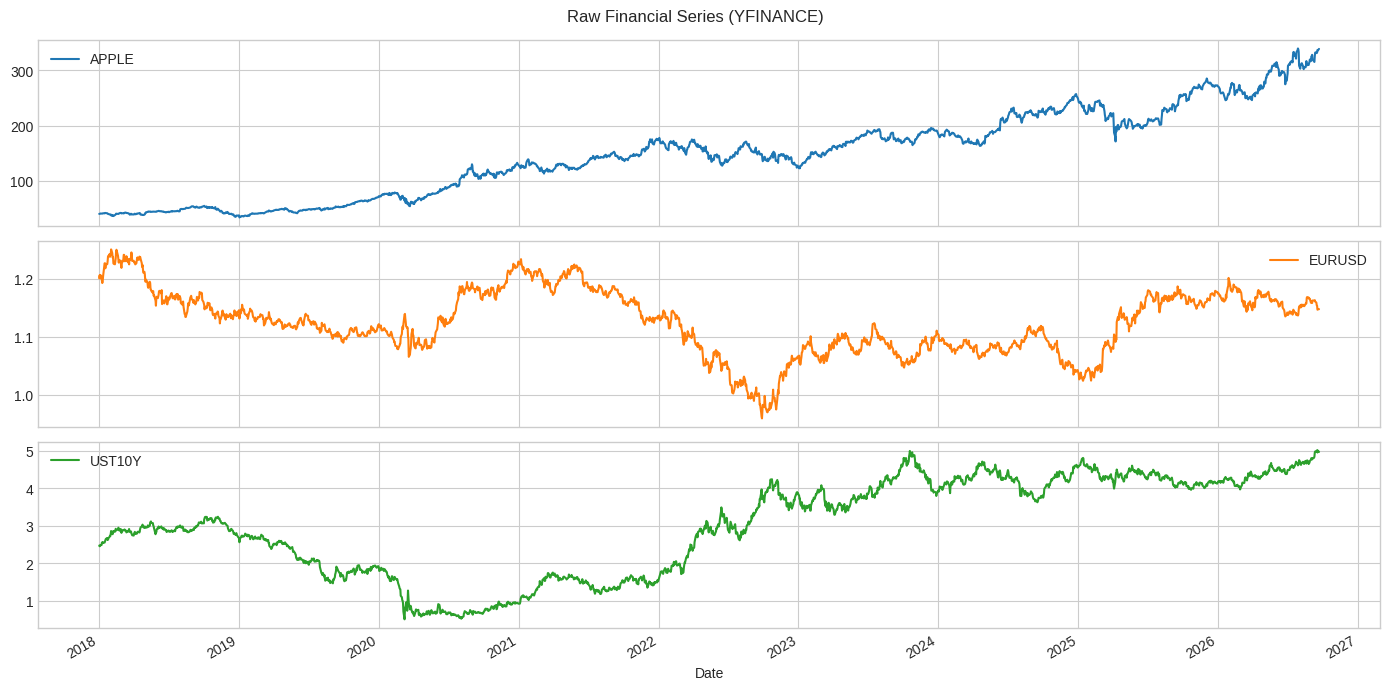

In [6]:
# ==============================================================================
# CONFIGURATION PANEL (EDIT INSTRUMENTS & DATA SOURCES HERE)
# ==============================================================================
DATA_SOURCE = "yfinance"  # Options: 'yfinance' or 'csv'
CSV_FILE_PATH = "M6. goog_eur_10.csv"

# Date range for Yahoo Finance downloads
START_DATE = "2018-01-01"
END_DATE = datetime.date.today().strftime("%Y-%m-%d")

# Instrument Mapping: Replaced GOOGLE with APPLE
INSTRUMENTS = [
    {
        "alias": "APPLE",          # Display name used across downstream analysis cells
        "yf_ticker": "AAPL",       # Yahoo Finance ticker for Apple Inc.
        "csv_column": "APPLE",     # CSV header column name (if using local CSV)
    },
    {
        "alias": "EURUSD",
        "yf_ticker": "EURUSD=X",
        "csv_column": "EURUSD",
    },
    {
        "alias": "UST10Y",
        "yf_ticker": "^TNX",
        "csv_column": "UST10Y",
    },
]


def load_financial_data(source="yfinance"):
    """Fetch financial data based on configurable instrument mappings."""
    aliases = [inst["alias"] for inst in INSTRUMENTS]

    if source.lower() == "yfinance":
        print(f"Fetching data from Yahoo Finance API for: {aliases}...")
        yf_tickers = [inst["yf_ticker"] for inst in INSTRUMENTS]
        raw = yf.download(yf_tickers, start=START_DATE, end=END_DATE)["Close"]

        # Rename columns to standardized aliases
        mapping = {inst["yf_ticker"]: inst["alias"] for inst in INSTRUMENTS}
        if len(INSTRUMENTS) == 1:
            df_out = pd.DataFrame({INSTRUMENTS[0]["alias"]: raw})
        else:
            df_out = raw.rename(columns=mapping)[aliases]

    elif source.lower() == "csv":
        print(f"Loading data from local CSV ({CSV_FILE_PATH}) for: {aliases}...")
        df_csv = pd.read_csv(CSV_FILE_PATH)
        df_csv["Date"] = pd.to_datetime(df_csv["Date"], format="%m/%d/%Y")
        df_csv.set_index("Date", inplace=True)

        mapping = {inst["csv_column"]: inst["alias"] for inst in INSTRUMENTS}
        csv_cols = [inst["csv_column"] for inst in INSTRUMENTS]
        df_out = df_csv[csv_cols].rename(columns=mapping)[aliases]

    else:
        raise ValueError("Invalid source specified. Use 'yfinance' or 'csv'.")

    # Clean missing values and sort chronologically
    df_out = df_out.dropna().sort_index()
    return df_out


# Load dataset based on config
data = load_financial_data(source=DATA_SOURCE)

# Visualize baseline raw time series
data.plot(subplots=True, title=f"Raw Financial Series ({DATA_SOURCE.upper()})")
plt.tight_layout()
plt.show()

In [7]:
def check_stationarity(df_input):
    """Run Augmented Dickey-Fuller (ADF) test across all configured columns."""
    results = {}
    for col in df_input.columns:
        adf = ADF(df_input[col])
        results[col] = {
            "Test Statistic": round(adf.stat, 4),
            "p-value": round(adf.pvalue, 4),
            "Is Stationary": adf.pvalue < 0.05,
        }
    return pd.DataFrame(results).T


print("--- ADF Test on Level Data ---")
print(check_stationarity(data))

# First-Differencing for stationarity I(1) -> I(0)
data_diff = data.diff().dropna()

print("\n--- ADF Test on First-Differenced Data ---")
print(check_stationarity(data_diff))

--- ADF Test on Level Data ---
       Test Statistic p-value Is Stationary
APPLE          0.4735   0.984         False
EURUSD        -2.3368  0.1604         False
UST10Y         -0.381  0.9132         False

--- ADF Test on First-Differenced Data ---
       Test Statistic p-value Is Stationary
APPLE        -22.4802     0.0          True
EURUSD       -19.4701     0.0          True
UST10Y       -35.0428     0.0          True


In [13]:
# ==============================================================================
# CELL 4: GRANGER CAUSALITY ANALYSIS (CLEAN FORMAT)
# ==============================================================================
# In statsmodels grangercausalitytests(data[[Y, X]]):
# Tests if X (column 1) Granger-causes Y (column 0)

var_A = INSTRUMENTS[0]["alias"]  # e.g., APPLE
var_B = INSTRUMENTS[1]["alias"]  # e.g., EURUSD

max_lag = 4

def run_granger_test(df, x_var, y_var, max_lags=4):
    """
    Runs Granger Causality Test to see if x_var Granger-causes y_var.
    Returns a clean summary DataFrame.
    """
    # Order: [Y, X] -> tests if X causes Y
    # Note: 'verbose=False' removed for compatibility with statsmodels >= 0.14
    test_result = grangercausalitytests(df[[y_var, x_var]], maxlag=max_lags)

    summary_data = []
    for lag in range(1, max_lags + 1):
        # Extract F-test statistic and p-value for the current lag
        f_stat = test_result[lag][0]['ssr_ftest'][0]
        p_val = test_result[lag][0]['ssr_ftest'][1]

        summary_data.append({
            "Lag": lag,
            "F-Statistic": round(f_stat, 4),
            "p-value": round(p_val, 4),
            "Significant (p < 0.05)": p_val < 0.05
        })

    return pd.DataFrame(summary_data)

print(f"--- Does {var_B} Granger-cause {var_A}? ---")
results_B_to_A = run_granger_test(data_diff, x_var=var_B, y_var=var_A, max_lags=max_lag)
print(results_B_to_A.to_string(index=False))

print(f"\n--- Does {var_A} Granger-cause {var_B}? ---")
results_A_to_B = run_granger_test(data_diff, x_var=var_A, y_var=var_B, max_lags=max_lag)
print(results_A_to_B.to_string(index=False))

--- Does EURUSD Granger-cause APPLE? ---
 Lag  F-Statistic  p-value  Significant (p < 0.05)
   1       5.4502   0.0197                    True
   2       3.2483   0.0390                    True
   3       2.3743   0.0684                   False
   4       1.9631   0.0976                   False

--- Does APPLE Granger-cause EURUSD? ---
 Lag  F-Statistic  p-value  Significant (p < 0.05)
   1      25.9259      0.0                    True
   2      15.3757      0.0                    True
   3      12.1722      0.0                    True
   4       9.1400      0.0                    True


In [14]:
model = VAR(data_diff)

# Lag selection using information criteria
lag_selection = model.select_order(maxlags=10)
print("--- VAR Lag Order Selection Criteria ---")
print(lag_selection.summary())

optimal_lag = lag_selection.aic
print(f"\nSelected Optimal Lag (AIC): {optimal_lag}")

# Fit VAR model via OLS
var_results = model.fit(optimal_lag)
print(var_results.summary())

--- VAR Lag Order Selection Criteria ---
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -14.23      -14.23   6.581e-07      -14.23
1       -14.29     -14.26*   6.217e-07     -14.28*
2      -14.29*      -14.24  6.204e-07*      -14.27
3       -14.29      -14.21   6.211e-07      -14.26
4       -14.29      -14.19   6.240e-07      -14.25
5       -14.28      -14.16   6.261e-07      -14.24
6       -14.28      -14.13   6.284e-07      -14.23
7       -14.28      -14.10   6.310e-07      -14.21
8       -14.28      -14.08   6.315e-07      -14.20
9       -14.28      -14.06   6.307e-07      -14.20
10      -14.28      -14.03   6.311e-07      -14.19
--------------------------------------------------

Selected Optimal Lag (AIC): 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 22, Sep, 2026
Time:                  

Eigenvalues of VAR(1) rep
0.1712220489364285
0.1712220489364285
0.0934371710462044
0.0934371710462044
0.23325099773577512
0.23325099773577512

Model Stability / Ergodicity Verified: True
Residual Whiteness p-value: 0.0122


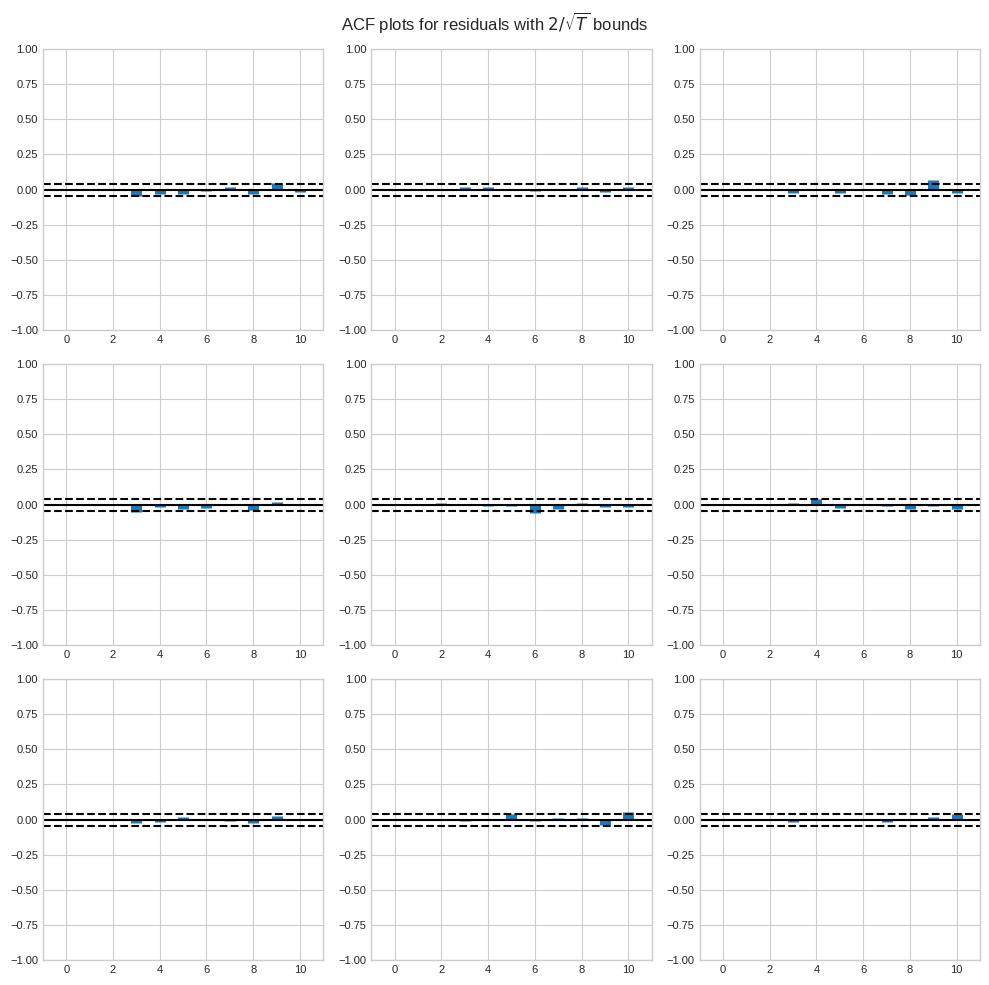

In [15]:
# Check polynomial roots for stability/ergodicity
is_stable = var_results.is_stable(verbose=True)
print(f"\nModel Stability / Ergodicity Verified: {is_stable}")

# Residual Serial Correlation Check
residual_acorr = var_results.test_whiteness(nlags=10)
print(f"Residual Whiteness p-value: {round(residual_acorr.pvalue, 4)}")

# Plot autocorrelation of residuals
var_results.plot_acorr()
plt.tight_layout()
plt.show()

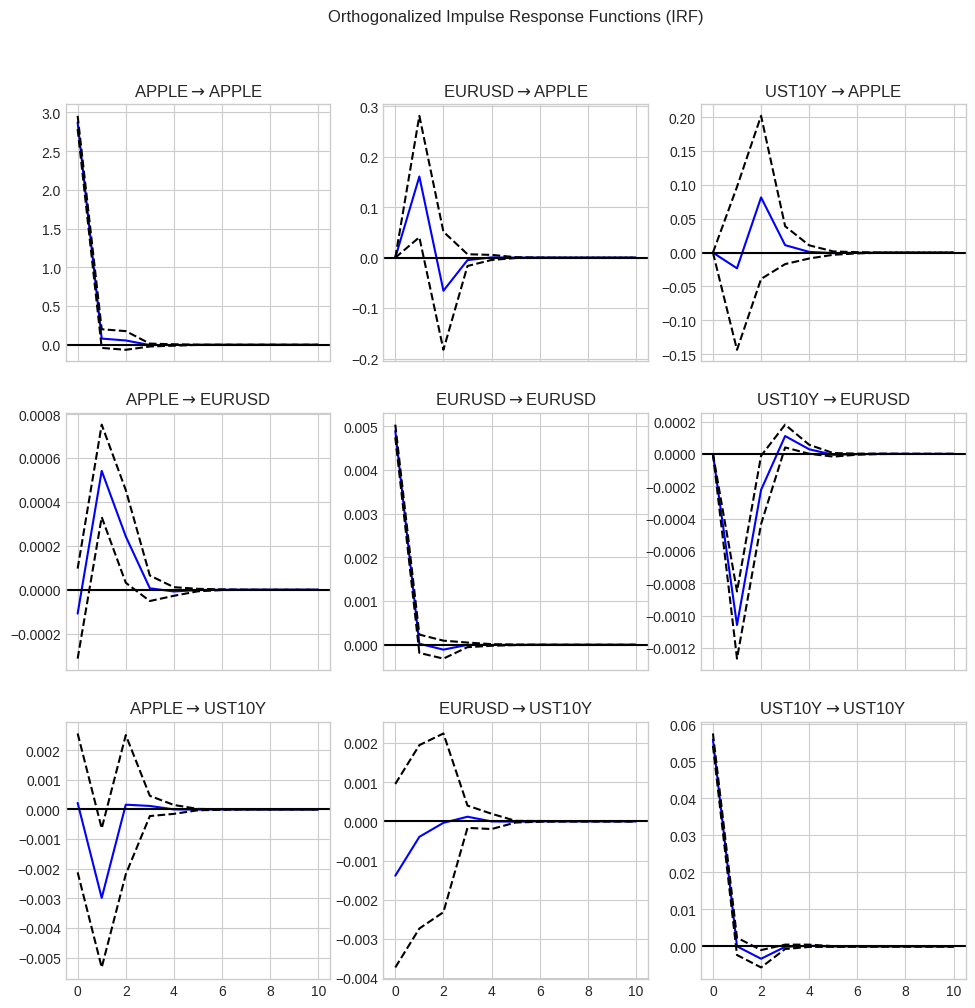

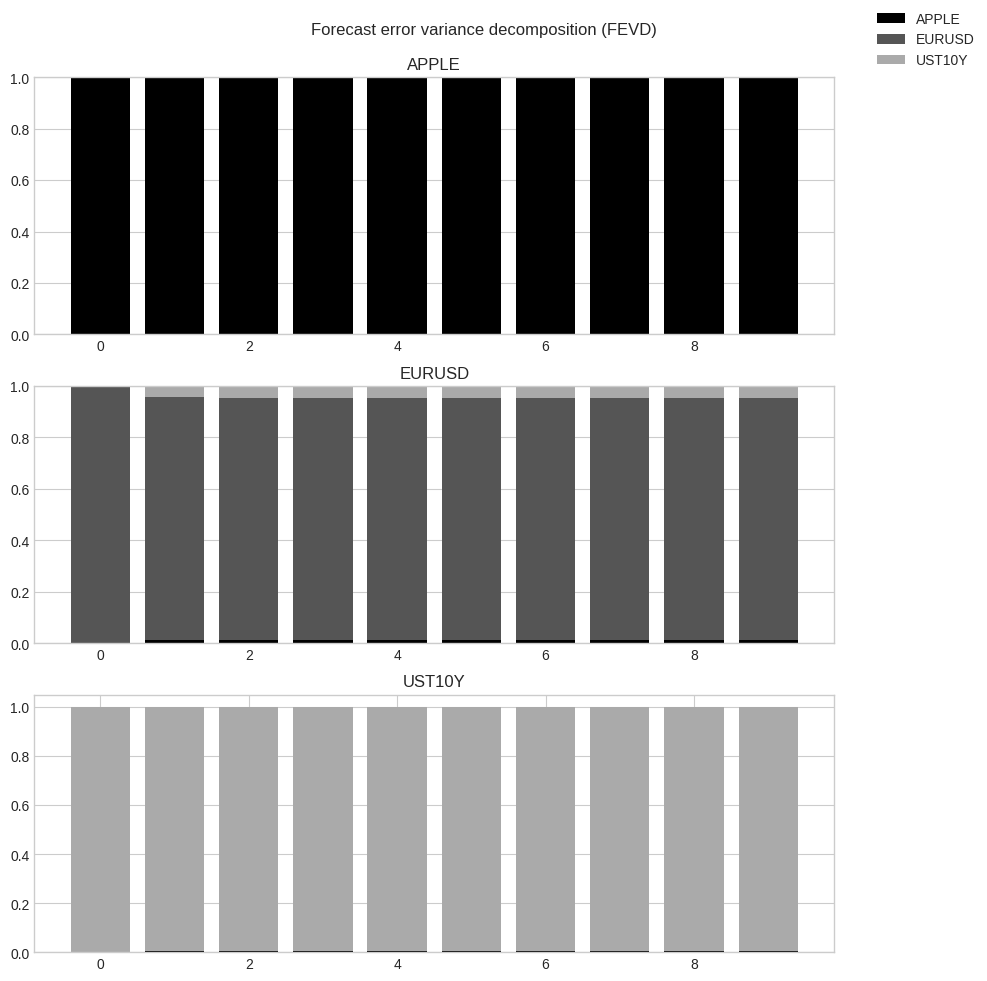

In [16]:
# Orthogonalized Impulse Response Functions
irf = var_results.irf(periods=10)
irf.plot(orth=True)
plt.suptitle("Orthogonalized Impulse Response Functions (IRF)", y=1.02)
plt.show()

# Forecast Error Variance Decomposition
fevd = var_results.fevd(periods=10)
fevd.plot()
plt.show()

--- Out-of-Sample Level Forecasts ---
Ticker           APPLE    EURUSD    UST10Y
2026-09-22  339.307558  1.148876  4.958108
2026-09-23  339.432505  1.149291  4.961482
2026-09-24  339.558975  1.149228  4.963006
2026-09-25  339.692396  1.149172  4.964032
2026-09-28  339.829262  1.149150  4.965160


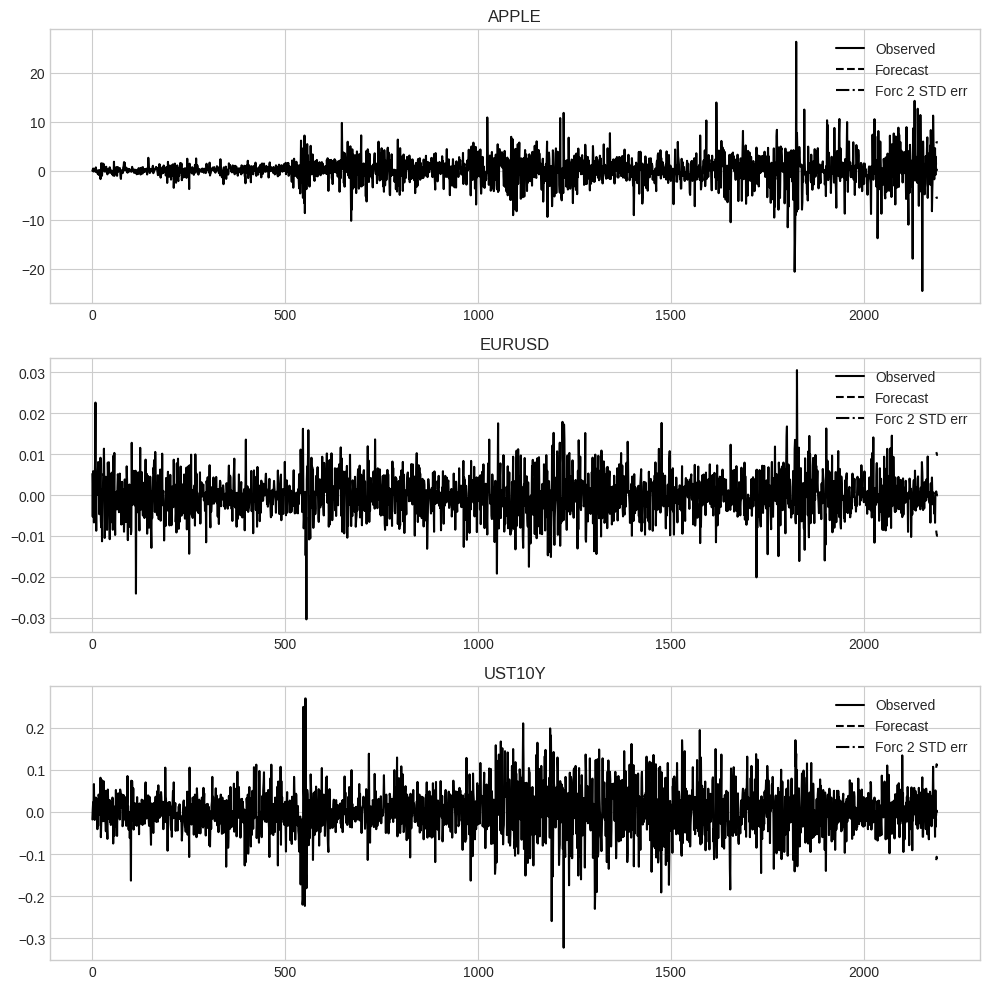

In [17]:
forecast_steps = 5

# Forecast differenced values
lag_order = var_results.k_ar
forecast_input = data_diff.values[-lag_order:]
fc_diff = var_results.forecast(y=forecast_input, steps=forecast_steps)

# Convert forecast array to DataFrame
fc_diff_df = pd.DataFrame(
    fc_diff,
    index=pd.date_range(
        start=data.index[-1] + pd.Timedelta(days=1),
        periods=forecast_steps,
        freq="B",
    ),
    columns=data.columns,
)

# Reconstruct predicted actual levels from original series
last_actual_levels = data.iloc[-1]
fc_levels_df = fc_diff_df.cumsum().add(last_actual_levels, axis=1)

print("--- Out-of-Sample Level Forecasts ---")
print(fc_levels_df)

# Plot forecasts
var_results.plot_forecast(forecast_steps)
plt.tight_layout()
plt.show()

--- 100-Step Ahead Level Forecasts ---
            APPLEForecast  EURUSDForecast  UST10YForecast
2026-09-22     339.307558        1.148876        4.958108
2026-09-23     339.432505        1.149291        4.961482
2026-09-24     339.558975        1.149228        4.963006
2026-09-25     339.692396        1.149172        4.964032
2026-09-28     339.829262        1.149150        4.965160


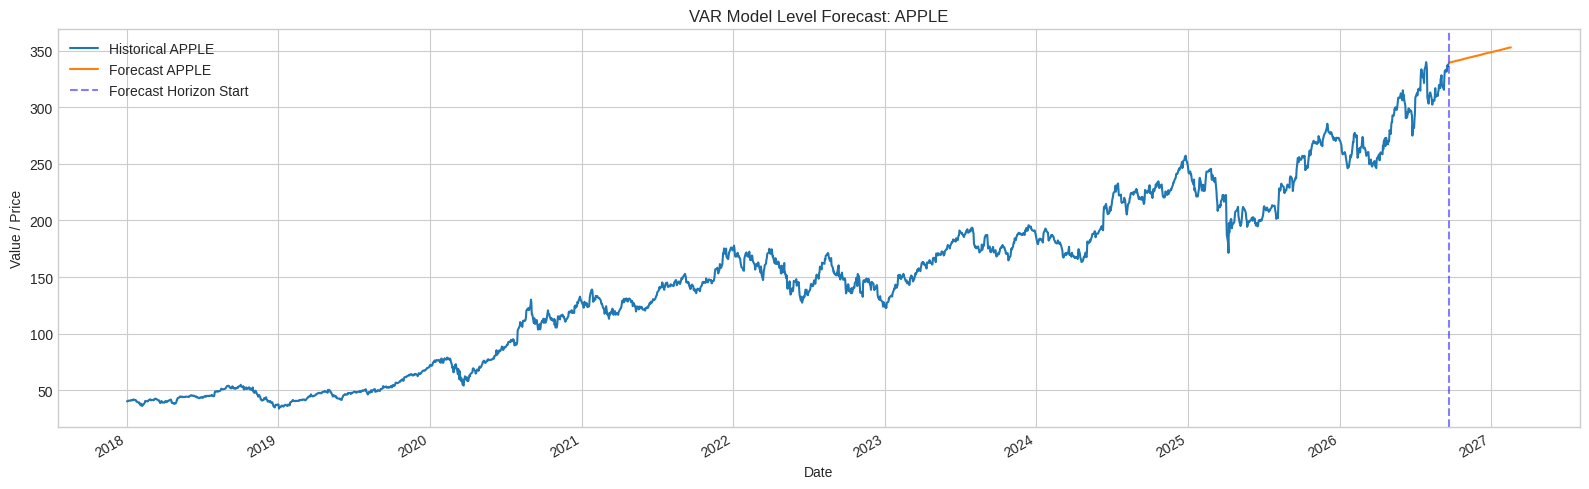

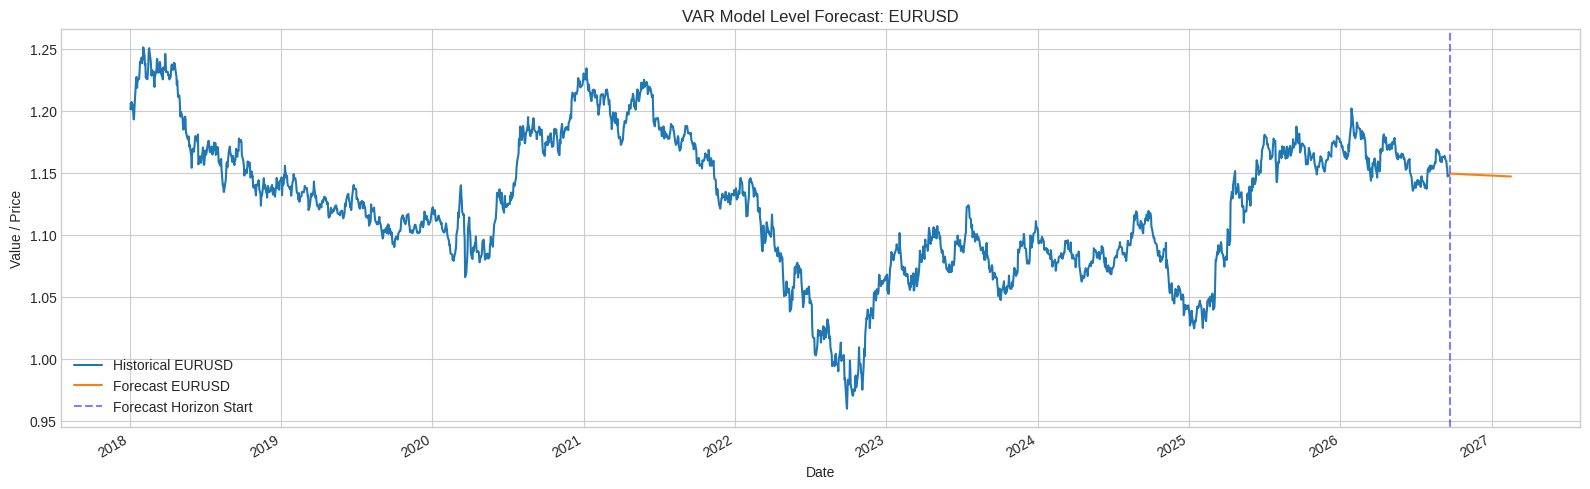

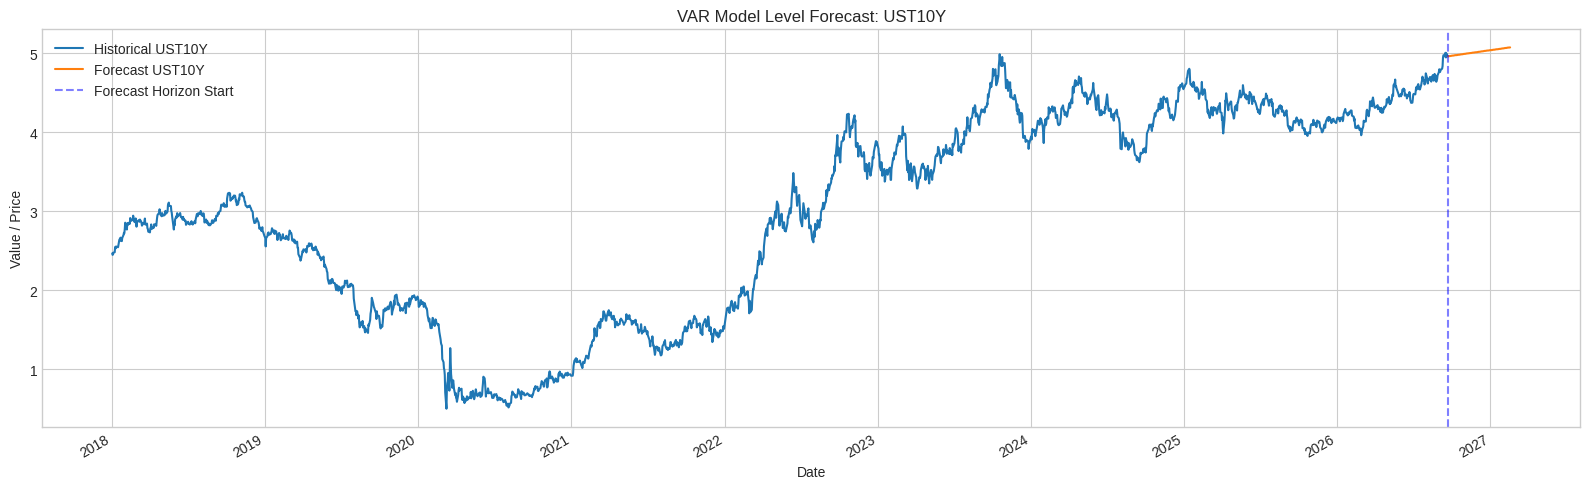

In [19]:
# ==============================================================================
# CELL 8: LINEAR DIFFERENCE LEVEL FORECASTING & RECONSTRUCTION
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

# Set forecast parameters
forecast_steps = 100

# 1. Generate out-of-sample forecasts on differenced data
lag_order = var_results.k_ar
forecast_input = data_diff.values[-lag_order:]
pred = var_results.forecast(y=forecast_input, steps=forecast_steps)

# 2. Extend business date index using US Federal Holiday Calendar
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
start_forecast_date = data.index[-1] + us_bd
forecast_idx = pd.date_range(start=start_forecast_date, periods=forecast_steps, freq=us_bd)

# Build DataFrame for differenced predictions
diff_cols = [f"{col}_1d" for col in data.columns]
df_forecast = pd.DataFrame(data=pred, index=forecast_idx, columns=diff_cols)

# 3. Simple Linear Reconstruction (CumSum + Last Level)
for col in data.columns:
    col_1d = f"{col}_1d"
    forecast_col = f"{col}Forecast"

    # Cumulative sum of daily linear differences added to last level
    df_forecast[forecast_col] = data[col].iloc[-1] + df_forecast[col_1d].cumsum()

# Display numerical forecast summary
forecast_summary_cols = [f"{col}Forecast" for col in data.columns]
print(f"--- {forecast_steps}-Step Ahead Level Forecasts ---")
print(df_forecast[forecast_summary_cols].head())

# 4. Plot historical data alongside forecasts
split_date = forecast_idx[0].strftime("%Y-%m-%d")

for col in data.columns:
    forecast_col = f"{col}Forecast"

    plt.figure(figsize=(16, 5))
    data[col].plot(legend=True, label=f"Historical {col}")
    df_forecast[forecast_col].plot(legend=True, label=f"Forecast {col}")
    plt.axvline(x=pd.to_datetime(split_date), color="b", alpha=0.5, linestyle="--", label="Forecast Horizon Start")
    plt.title(f"VAR Model Level Forecast: {col}")
    plt.ylabel("Value / Price")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()